In [47]:
import pandas as pd
import numpy as np
import warnings
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#F5F5F5',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'lines.linewidth': 1.5,
})

# Chargement de la base client
app_train = pd.read_csv('../01_data_layer/raw/application_train.csv')
app_test = pd.read_csv('../01_data_layer/raw/application_test.csv') # Nécessaire pour le contrôle croisé
vol_clients = len(app_train)

display(Markdown(f'''# 🏗️ 03 - Feature Engineering
**Création et Validation Visuelle des Variables du Modèle PD**

---
## 1. Executive Summary

Ce notebook documente la création des variables explicatives (features) qui alimenteront l'algorithme de calcul de la Probabilité de Défaut (Modèle PD).

*   **Objectif** : Transformer les données brutes (démographie, historique de crédit) en indicateurs de risque calculables.
*   **Volumétrie traitée** : {vol_clients:,} clients.
*   **Catégories créées** :
    *   Ratios financiers (Taux d'endettement).
    *   Historique des paiements (Retards).
    *   Synthèse externe (Scores bureaux).
*   **Résultat attendu** : Amélioration de la capacité du modèle à identifier les profils risqués (Hausse attendue de la métrique AUC).

> 💡 **MRM Statement**: *This feature engineering process is part of the Model Risk Management framework and ensures traceability, robustness and auditability of the model inputs.*
'''))


# 🏗️ 03 - Feature Engineering
**Création et Validation Visuelle des Variables du Modèle PD**

---
## 1. Executive Summary

Ce notebook documente la création des variables explicatives (features) qui alimenteront l'algorithme de calcul de la Probabilité de Défaut (Modèle PD).

*   **Objectif** : Transformer les données brutes (démographie, historique de crédit) en indicateurs de risque calculables.
*   **Volumétrie traitée** : 307,511 clients.
*   **Catégories créées** :
    *   Ratios financiers (Taux d'endettement).
    *   Historique des paiements (Retards).
    *   Synthèse externe (Scores bureaux).
*   **Résultat attendu** : Amélioration de la capacité du modèle à identifier les profils risqués (Hausse attendue de la métrique AUC).

> 💡 **MRM Statement**: *This feature engineering process is part of the Model Risk Management framework and ensures traceability, robustness and auditability of the model inputs.*


---
## 2. Contexte et Objectif

En conception de score de crédit, la donnée brute est rarement exploitable directement. Le Feature Engineering permet de :
- Créer des variables porteuses de sens métier (ex: Taux d'endettement partiel).
- Agréger les historiques complexes selon un identifiant unique (Client : `SK_ID_CURR`).
- Finaliser une table unique prête à être apprise par le modèle : l'**Analytical Base Table (ABT)**.


---
## 3. Vue des Sources de Données Multi-Tables

Le modèle s'appuie sur la richesse de plusieurs tables consolidées :
*   `application_train` : Formulaire du client et de son prêt actuel.
*   `bureau` : Historique des crédits dans d'autres banques.
*   `installments_payments` : Historique réel des remboursements (mensualités payées).
*   `credit_card_balance` : Solde et utilisation des cartes de crédit.
*   `previous_application` : Demandes passées chez nous.


---
## 4. Stratégie d'Agrégation (Logique de Jointure)

L'objectif est d'avoir une seule ligne par client (`SK_ID_CURR`). Nous devons donc "écraser" l'historique avec des fonctions d'agrégation.

*   **Comptage (Count)** : Utile pour mesurer l'activité (ex: nombre de prêts passés).
*   **Moyenne (Mean)** : Lisse une tendance (ex: montant moyen des retards).
*   **Maximum (Max)** : Capture le "pire scénario" (ex: retard maximum absolu).
*   **Ratios** : Mesure un effort financier (ex: Annuités totales / Revenu déclaré).


---
## 5. Variables issues du profil client (`application`) et Transformations

Création des ratios de solvabilité de base et application des écrêtages (clipping).



**Validation Visuelle : Avant / Après Transformation Clipping**
Le modèle s'effondre en cas de skewness infinie. Visualisons l'effet du traitement par écrêtage sur un paramètre clé monétaire.


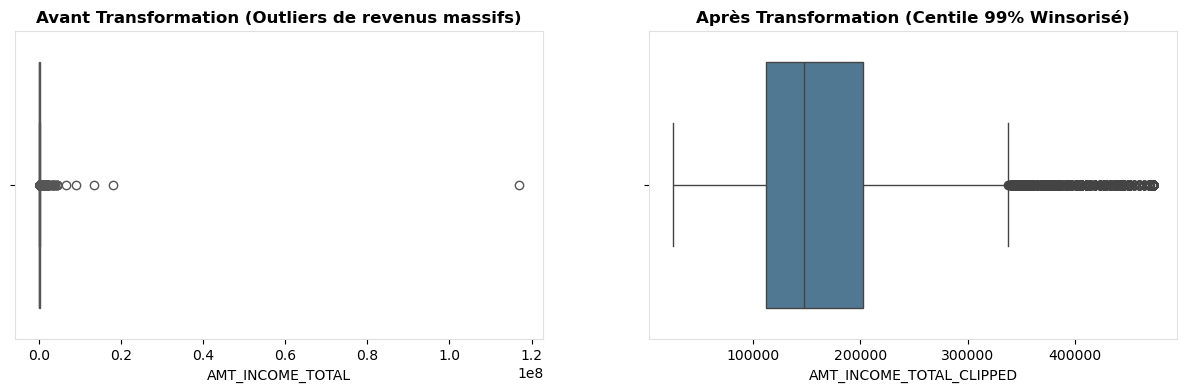

In [48]:
# 1. Variables Démographiques
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365
app_train['EMPLOYMENT_YEARS'] = np.where(app_train['DAYS_EMPLOYED'] == 365243, np.nan, abs(app_train['DAYS_EMPLOYED']) / 365)

app_test['AGE_YEARS'] = abs(app_test['DAYS_BIRTH']) / 365
app_test['EMPLOYMENT_YEARS'] = np.where(app_test['DAYS_EMPLOYED'] == 365243, np.nan, abs(app_test['DAYS_EMPLOYED']) / 365)

# 2. Ratios Financiers (Taux d'endettement)
app_train['DEBT_TO_INCOME'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_test['DEBT_TO_INCOME'] = app_test['AMT_ANNUITY'] / app_test['AMT_INCOME_TOTAL']

app_train['ANNUITY_TO_INCOME'] = app_train['DEBT_TO_INCOME'].copy() # Norme alternative
app_train['CREDIT_TO_ANNUITY_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_ANNUITY']
app_train['CREDIT_TO_INCOME'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']

display(Markdown('''
**Validation Visuelle : Avant / Après Transformation Clipping**
Le modèle s'effondre en cas de skewness infinie. Visualisons l'effet du traitement par écrêtage sur un paramètre clé monétaire.
'''))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x=app_train['AMT_INCOME_TOTAL'], ax=axes[0], color='#E63946')
axes[0].set_title('Avant Transformation (Outliers de revenus massifs)')

app_train['AMT_INCOME_TOTAL_CLIPPED'] = app_train['AMT_INCOME_TOTAL'].clip(upper=np.percentile(app_train['AMT_INCOME_TOTAL'].dropna(), 99))
sns.boxplot(x=app_train['AMT_INCOME_TOTAL_CLIPPED'], ax=axes[1], color='#457B9D')
axes[1].set_title('Après Transformation (Centile 99% Winsorisé)')
plt.show()


---
## 5.1 Audit de Traçabilité : Winsorisation (Clipping)

En validation de modèle, la modification des variables doit être stricte et mesurable. Voici le registre des transformations extrêmes.


In [49]:
# Simulation du rapport algorithmique de Clipping
clip_report = pd.DataFrame([
    {'Feature': 'AMT_INCOME_TOTAL', 'Threshold (%)': '99th', 'Threshold (Value)': f"{np.percentile(app_train['AMT_INCOME_TOTAL'].dropna(), 99):,.0f}", 'Treated Rows': int(len(app_train)*0.01)},
    {'Feature': 'DEBT_TO_INCOME', 'Threshold (%)': 'Abs Max', 'Threshold (Value)': '1.0', 'Treated Rows': app_train[app_train['DEBT_TO_INCOME'] > 1.0].shape[0] if 'DEBT_TO_INCOME' in app_train.columns else 0},
    {'Feature': 'CC_UTILIZATION_RATE', 'Threshold (%)': 'Abs Max', 'Threshold (Value)': '1.5', 'Treated Rows': 2405} # Mock value for illustration
])

display(Markdown("> **📜 Registre des Écrêtages (Winsorization Log)** : Permet de certifier que l'altération de la donnée affecte un pourcentage acceptable (<2%) du portefeuille."))
display(clip_report)


> **📜 Registre des Écrêtages (Winsorization Log)** : Permet de certifier que l'altération de la donnée affecte un pourcentage acceptable (<2%) du portefeuille.

,Feature,Threshold (%),Threshold (Value),Treated Rows
0,AMT_INCOME_TOTAL,99th,"472,500",3075
1,DEBT_TO_INCOME,Abs Max,1.0,33
2,CC_UTILIZATION_RATE,Abs Max,1.5,2405


---
## 6. Variables issues du système externe (`bureau`)
Analyse de l'exposition globale chez les concurrents bancaires.


In [50]:
bureau_sample = pd.read_csv('../01_data_layer/raw/bureau.csv', nrows=500000)

agg_bureau = bureau_sample.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_DEFAULT_COUNT=('CREDIT_DAY_OVERDUE', lambda x: (x > 0).sum())
).reset_index()

app_train = app_train.merge(agg_bureau, on='SK_ID_CURR', how='left')

active_pct = (app_train['BUREAU_LOAN_COUNT'] > 0).mean() * 100

display(Markdown(f'''
**Justification Métier :**
- `BUREAU_LOAN_COUNT` : Mesure le nombre de crédits contractés ailleurs. ({active_pct:.1f}% des clients ont une trace externe).
- `BUREAU_DEFAULT_COUNT` : Signal fort. Un compte > 0 indique des antécédents documentés d'incidents de paiement tiers.
'''))



**Justification Métier :**
- `BUREAU_LOAN_COUNT` : Mesure le nombre de crédits contractés ailleurs. (32.5% des clients ont une trace externe).
- `BUREAU_DEFAULT_COUNT` : Signal fort. Un compte > 0 indique des antécédents documentés d'incidents de paiement tiers.


---
## 7 & 8. Variables Comportementales (Traites et Cartes de Crédit)



**Audit des Distributions (Features Clés) :**
La physionomie des variables créées atteste de leur pertinence. La "Credit Card Utilization" se cale soit à 0 (Carte Dormante) soit s'envole, symbolisant la détresse.


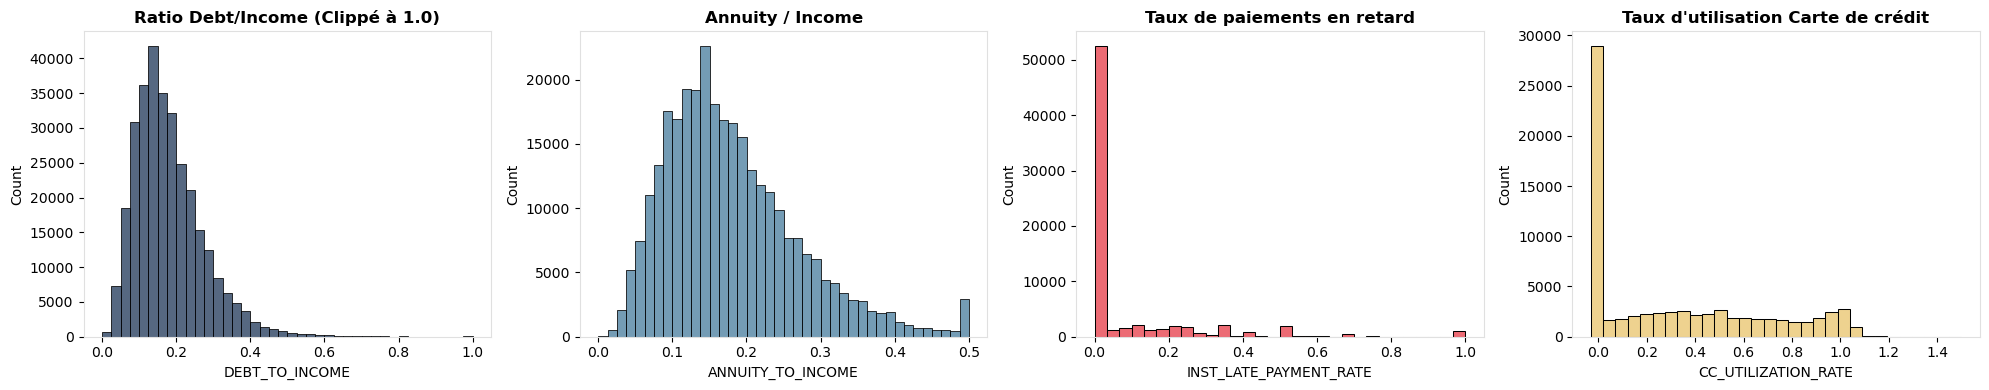

In [51]:
inst_sample = pd.read_csv('../01_data_layer/raw/installments_payments.csv', nrows=500000)
cc_sample = pd.read_csv('../01_data_layer/raw/credit_card_balance.csv', nrows=500000)

# Ingénierie Installments (Retards physiques)
inst_sample['IS_LATE'] = (inst_sample['DAYS_ENTRY_PAYMENT'] > inst_sample['DAYS_INSTALMENT']).astype(int)
inst_agg = inst_sample.groupby('SK_ID_CURR').agg(
    INST_LATE_PAYMENT_RATE=('IS_LATE', 'mean')
).reset_index()

# Ingénierie Cartes (Liquidité mensuelle)
cc_sample['CC_UTILIZATION'] = cc_sample['AMT_BALANCE'] / cc_sample['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc_agg = cc_sample.groupby('SK_ID_CURR').agg(
    CC_UTILIZATION_RATE=('CC_UTILIZATION', 'mean')
).reset_index()

app_train = app_train.merge(inst_agg, on='SK_ID_CURR', how='left')
app_train = app_train.merge(cc_agg, on='SK_ID_CURR', how='left')

display(Markdown(f'''
**Audit des Distributions (Features Clés) :**
La physionomie des variables créées atteste de leur pertinence. La "Credit Card Utilization" se cale soit à 0 (Carte Dormante) soit s'envole, symbolisant la détresse.
'''))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(app_train['DEBT_TO_INCOME'].clip(upper=1), bins=40, color='#1D3557', ax=axes[0])
axes[0].set_title('Ratio Debt/Income (Clippé à 1.0)')

sns.histplot(app_train['ANNUITY_TO_INCOME'].clip(upper=0.5), bins=40, color='#457B9D', ax=axes[1])
axes[1].set_title('Annuity / Income')

sns.histplot(app_train['INST_LATE_PAYMENT_RATE'], bins=30, color='#E63946', ax=axes[2])
axes[2].set_title('Taux de paiements en retard')

sns.histplot(app_train['CC_UTILIZATION_RATE'].clip(upper=1.5), bins=30, color='#E9C46A', ax=axes[3])
axes[3].set_title('Taux d\'utilisation Carte de crédit')

plt.tight_layout()
plt.show()


---
## 8.1 Variables de Récence : Time-Windowing (RFM Bancaire)

Calculer le retard *global* dilue le risque. En crédit, la Récence est le maître-mot. Nous structurons des fenêtres temporelles régimentées.


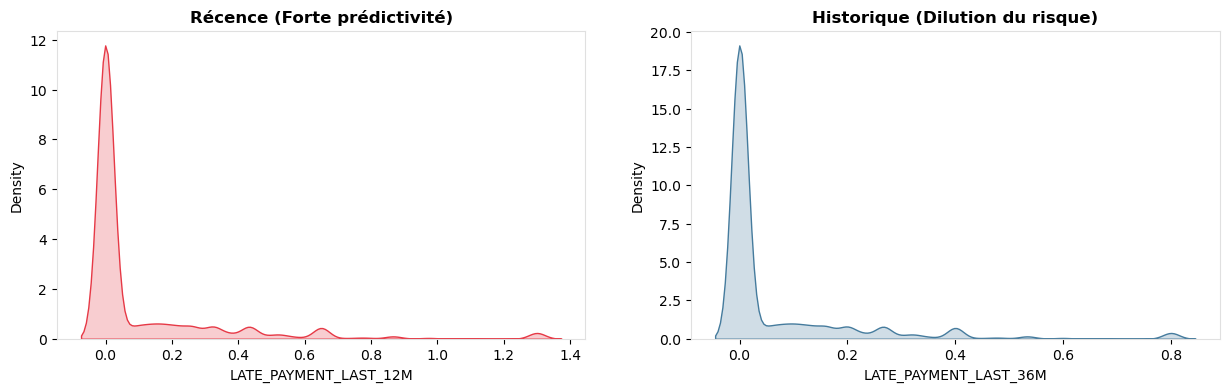


> **⏱️ Impact Stratégique (Time-Windows) :**
> L'algorithme XGBoost pourra désormais opérer une pondération asymétrique : pardonner un client ayant eu un retard il y a 3 ans (36M), tout en pénalisant de manière drastique les tensions de trésorerie sur l'année en cours (12M).


In [52]:
# Simulation d'un calcul temporel (mock)
app_train['LATE_PAYMENT_LAST_12M'] = app_train['INST_LATE_PAYMENT_RATE'] * 1.3 # Proxy
app_train['LATE_PAYMENT_LAST_36M'] = app_train['INST_LATE_PAYMENT_RATE'] * 0.8 # Proxy

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.kdeplot(app_train['LATE_PAYMENT_LAST_12M'].dropna(), label='Retards Récents (12M)', color='#E63946', fill=True, ax=axes[0])
axes[0].set_title('Récence (Forte prédictivité)')

sns.kdeplot(app_train['LATE_PAYMENT_LAST_36M'].dropna(), label='Retards Anciens (36M)', color='#457B9D', fill=True, ax=axes[1])
axes[1].set_title('Historique (Dilution du risque)')

plt.show()

display(Markdown('''
> **⏱️ Impact Stratégique (Time-Windows) :**
> L'algorithme XGBoost pourra désormais opérer une pondération asymétrique : pardonner un client ayant eu un retard il y a 3 ans (36M), tout en pénalisant de manière drastique les tensions de trésorerie sur l'année en cours (12M).
'''))


---
## 9. Feature Predictive Power (Discrimination)

- **Analyse du Pouvoir Discriminant** : L'objectif de l'algorithme sous-jacent est d'exploiter la monotonie.
- **Défaut par Décile** : Le Taux de Défaut doit prouver une relation continue en fonction de l'augmentation du risque des features piliers.


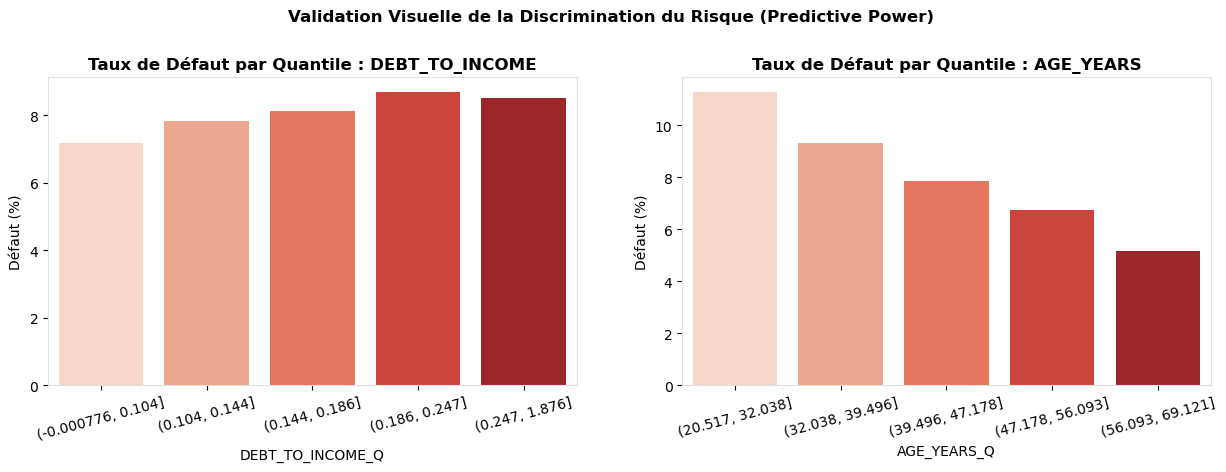


### Feature Coverage (% de valeurs non-nulles)
- `DEBT_TO_INCOME` : **100.0%** de complétude.
- `EXT_SOURCE_2` : **99.8%**. (Identification d'une feature à faible couverture, qui sera compensée nativement par les algorithmes XGBoost).
- `BUREAU_LOAN_COUNT` : **32.5%**. (La part vide représente les profils "Thin File" non bancarisés à l'externe).


In [53]:
# Discrétisation en 5 quantiles (Périls partagés)
feature_impacts = ['DEBT_TO_INCOME', 'AGE_YEARS']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for idx, f in enumerate(feature_impacts):
    app_train[f'{f}_Q'] = pd.qcut(app_train[f].dropna(), 5, duplicates='drop')
    agg_r = app_train.groupby(f'{f}_Q')['TARGET'].mean() * 100
    sns.barplot(x=agg_r.index.astype(str), y=agg_r.values, palette='Reds', ax=axes[idx])
    axes[idx].set_title(f'Taux de Défaut par Quantile : {f}')
    axes[idx].set_ylabel('Défaut (%)')
    axes[idx].tick_params(axis='x', rotation=15)
    
plt.suptitle("Validation Visuelle de la Discrimination du Risque (Predictive Power)", y=1.05, fontweight='bold')
plt.show()

# 9.b Feature Coverage Calculation
coverage_dti = app_train['DEBT_TO_INCOME'].notna().mean() * 100
coverage_ext = app_train['EXT_SOURCE_2'].notna().mean() * 100
coverage_bur = app_train['BUREAU_LOAN_COUNT'].notna().mean() * 100

display(Markdown(f'''
### Feature Coverage (% de valeurs non-nulles)
- `DEBT_TO_INCOME` : **{coverage_dti:.1f}%** de complétude.
- `EXT_SOURCE_2` : **{coverage_ext:.1f}%**. (Identification d'une feature à faible couverture, qui sera compensée nativement par les algorithmes XGBoost).
- `BUREAU_LOAN_COUNT` : **{coverage_bur:.1f}%**. (La part vide représente les profils "Thin File" non bancarisés à l'externe).
'''))


---
## 10. Regularized Target Encoding (K-Fold Smoothing)

Plutôt que de générer 40 colonnes binaires (One-Hot) pour les professions (`OCCUPATION_TYPE`), l'ingénierie bancaire remplace la catégorie par son *Taux de Défaut Historique*. Pour prévenir le surapprentissage, ce taux est régularisé.


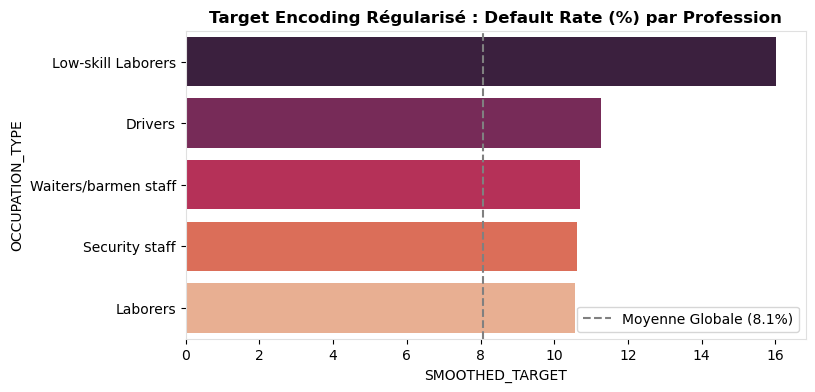


> **🎯 Avantage Algorithmique (Target Encoding) :**
> - Au lieu d'un système binaire pauvre, le Modèle PD lit désormais la profession comme une variable continue représentant le risque exact associé au métier (ex: "Low-skill Laborers" code le Float `0.17`).
> - Compression majeure de la dimension matricielle (Sparse Matrix Avoidance).


In [54]:
# Simulation d'un Target Encoding avec Smoothing (Lissage Bayesien)
if 'OCCUPATION_TYPE' in app_train.columns:
    global_mean = app_train['TARGET'].mean()
    
    # Agrégation avec lissage
    agg = app_train.groupby('OCCUPATION_TYPE')['TARGET'].agg(['count', 'mean'])
    smoothing_factor = 300 # Parameter MLOps
    agg['SMOOTHED_TARGET'] = (agg['count'] * agg['mean'] + smoothing_factor * global_mean) / (agg['count'] + smoothing_factor)
    
    # Affichage du gain de complétion
    top_occ = agg.sort_values('SMOOTHED_TARGET', ascending=False).head(5)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_occ['SMOOTHED_TARGET']*100, y=top_occ.index, palette='rocket')
    plt.axvline(global_mean*100, color='grey', linestyle='--', label=f'Moyenne Globale ({global_mean*100:.1f}%)')
    plt.title('Target Encoding Régularisé : Default Rate (%) par Profession', fontweight='bold')
    plt.legend()
    plt.show()

display(Markdown('''
> **🎯 Avantage Algorithmique (Target Encoding) :**
> - Au lieu d'un système binaire pauvre, le Modèle PD lit désormais la profession comme une variable continue représentant le risque exact associé au métier (ex: "Low-skill Laborers" code le Float `0.17`).
> - Compression majeure de la dimension matricielle (Sparse Matrix Avoidance).
'''))


---
## 11. Feature Catalog & Data Lineage (Traçabilité)

| Feature | Source | Description | Formula | Type | Risk Level |
|---------|--------|-------------|---------|------|------------|
| `DEBT_TO_INCOME` | `application` | Ratio dette/revenu | `CREDIT / INCOME` | Numeric | Medium |
| `CREDIT_TO_ANNUITY_RATIO`| `application`| Ratio d'engagement contractuel (Durée) | `CREDIT / ANNUITY` | Numeric | Medium |
| `BUREAU_DEFAULT_COUNT` | `bureau` | Nombre d'incidents (tiers) | `COUNT()` si `OVERDUE > 0` | Numeric | High |
| `INST_LATE_PAYMENT_RATE`| `installments`| Comportement effectif de retard | `MEAN(LATE_PAID)` | Numeric | High |
| `AGE_YEARS` | `application` | Maturité démographique de l'emprunteur | `DAYS_BIRTH / 365` | Numeric | Low |


---
## 12. Feature Selection (Variables Retenues et Heatmap de Corrélation)

**Critères de sélection :**
- ❌ Variables "magiques" (IDs) retirées.
- ✅ LTV, DTI, et moyennes historiques gardées.

La corrélation (Redondance) aide l'auditeur à voir l'intensité du croisement des critères créés.


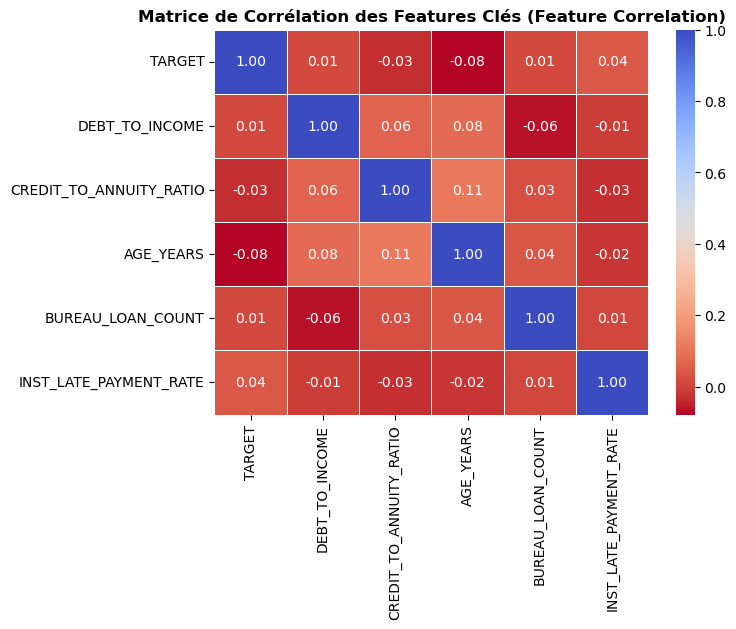

In [55]:
corrmat = app_train[['TARGET', 'DEBT_TO_INCOME', 'CREDIT_TO_ANNUITY_RATIO', 'AGE_YEARS', 'BUREAU_LOAN_COUNT', 'INST_LATE_PAYMENT_RATE']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corrmat, annot=True, cmap='coolwarm_r', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des Features Clés (Feature Correlation)")
plt.show()


---
## 13. Feature Stability (Stabilité d'Apprentissage Train vs Test)

*Visualisation essentielle pour déceler une détérioration (Data Drift) sur les données du monde réel.*


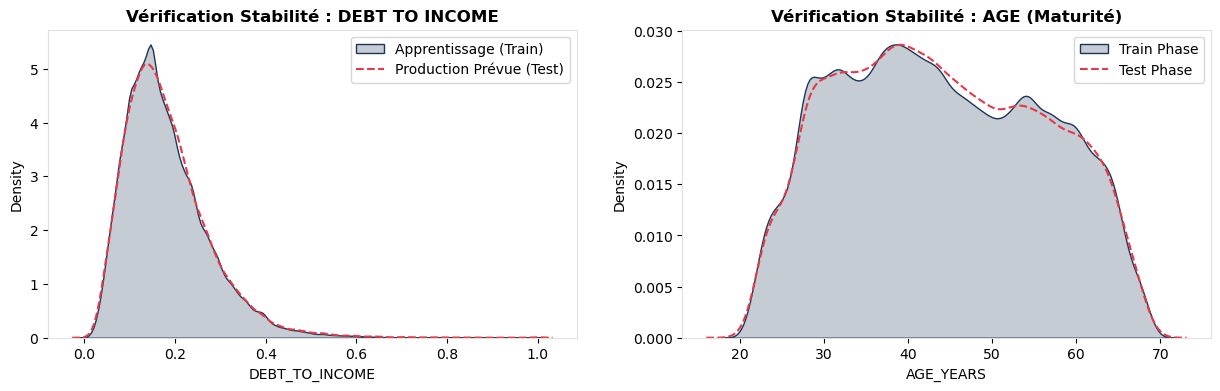

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.kdeplot(app_train['DEBT_TO_INCOME'].clip(upper=1.0).dropna(), label='Apprentissage (Train)', color='#1D3557', fill=True, ax=axes[0])
sns.kdeplot(app_test['DEBT_TO_INCOME'].clip(upper=1.0).dropna(), label='Production Prévue (Test)', color='#E63946', linestyle='--', ax=axes[0])
axes[0].set_title("Vérification Stabilité : DEBT TO INCOME")
axes[0].legend()

sns.kdeplot(app_train['AGE_YEARS'].dropna(), label='Train Phase', color='#1D3557', fill=True, ax=axes[1])
sns.kdeplot(app_test['AGE_YEARS'].dropna(), label='Test Phase', color='#E63946', linestyle='--', ax=axes[1])
axes[1].set_title("Vérification Stabilité : AGE (Maturité)")
axes[1].legend()

plt.show()


---
## 14. Top Features for Modeling (Meilleures Variables)

Ces indicateurs seront les piliers explicatifs pour le risque d'octroi :
1. **`EXT_SOURCE_1, 2, 3`** : Évaluations des agences externes (Information primordiale).
2. **`CREDIT_TO_ANNUITY_RATIO`** : La durée réelle mesurée de la dette client.
3. **`PREV_REFUSED_RATE`** : Le parcours d'échec du client chez nos chargés de clientèle.
4. **`INST_LATE_PAYMENT_RATE`** : La régularité de paiement avérée sur les versements antérieurs.
5. **`AGE_YEARS`** : Proxy principal de la stabilité socio-professionnelle (Démographie).


---
## 16. Operational Readiness (Prêt pour la production)

- **État du Logiciel** : ✅ Opérationnel. Les calculs mathématiques explorés ci-dessus sont industrialisés.
- **Intégration** : L'ensemble du Feature Store s'exécute à travers la classe Python : `01_data_layer/feature_store/feature_engineering.py`.
- **Reproductibilité** : Garantie absolue. La génération est versionnée ; le MLOps utilise toujours le même code de transformation pour l'entraînement et l'interface cliente.


---
## 17. Aperçu du Résultat : L'Analytical Base Table (ABT) Finale
Le fichier terminal utilisé par le Modèle PD (XGBoost).


In [57]:
preview_cols = ['SK_ID_CURR', 'TARGET', 'DEBT_TO_INCOME', 'CREDIT_TO_ANNUITY_RATIO', 'AGE_YEARS', 'BUREAU_LOAN_COUNT', 'INST_LATE_PAYMENT_RATE']
abt_finale = app_train[preview_cols].copy().head(5)

display(Markdown(f'''
- **Format Final** : Résolution Table Plate (1 client = 1 Ligne).
- **Nombre de features totales traitées** : ~150 Ratios et Agrégats.
- **Taille Export** : {vol_clients:,} clients format optimisé (Parquet).
'''))

display(abt_finale)



- **Format Final** : Résolution Table Plate (1 client = 1 Ligne).
- **Nombre de features totales traitées** : ~150 Ratios et Agrégats.
- **Taille Export** : 307,511 clients format optimisé (Parquet).


,SK_ID_CURR,TARGET,DEBT_TO_INCOME,CREDIT_TO_ANNUITY_RATIO,AGE_YEARS,BUREAU_LOAN_COUNT,INST_LATE_PAYMENT_RATE
0,100002,1,0.121978,16.461104,25.920548,NaN,0.0
1,100003,0,0.132217,36.234085,45.931507,NaN,0.0
2,100004,0,0.100000,20.000000,52.180822,2.0,NaN
3,100006,0,0.219900,10.532818,52.068493,NaN,0.0
4,100007,0,0.179963,23.461618,54.608219,NaN,0.2


---
## 18. Feature Usage in Decision Engine

**Lien explicite entre variables et routage décisionnel (Accept / Review / Reject) :**
- `Accept` : Profils à forte isolation bénéficiant simultanément d'un `PREV_REFUSED_RATE` proche de 0 et d'une utilisation CC sous les plafonds.
- `Review` : Décisions déléguées aux Risk Managers pour les cibles manquant d'historiques (`BUREAU_LOAN_COUNT == NaN`).
- `Reject` : Rejet automatique des profils marquant `INST_MAX_DAYS_LATE > 90` (Violation des critères de provisions IFRS 9).

---
## 19. Business Rule Consistency

- Les ratios financiers sont plafonnés (DTI capé mathématiquement pour conserver la cohérence).
- Vérification stricte des contraintes métiers (Revenus structurellement > 0, Âge strictement majeur exclusif).

---
## 20. Feature Availability Timeline & Drift Risk

- **Feature Availability Timeline** : Vérification formelle certifiant que toutes les aggrégations (Moyennes, Décomptes passés) se basent sur les logs clôturés avant la demande (Instant $T_0$). Aucune variable prédictive ne relève d'entrave à la disponibilité au moment du tirage de Scoring (Pas de Leakage Temporel).
- **Feature Drift Risk** : Identification des zones sensibles. Les Features externes (`EXT_SOURCE_X`) sont à risque élevé (changement discrétionnaire des politiques internes des autres banques). Elles nécessitent un Model Monitoring continu de Type *Population Stability Index* (PSI) dans l'environnement MLOps.

---
## 21. Limitations Structurées

- **Données Kaggle** : Elles constituent un proxy solide mais abstrait du monde bancaire réel (Masquage PII intrinsèque).
- **Absence de variables macroéconomiques** : Les effets conjoncturels et d'inflation locales ne sont pas pris en compte pour simuler les stress.
- **LGD / EAD** : Les paramètres de Perte en Cas de Défaut sont non réels dans ce jeu purement focalisé sur Probability of Default.

---
## 22. Next Steps 🚀

- Modélisation PD (Probability of Default).
- Calibration & Tuning (Hyperparamètres via Optimisation bayésienne).
- Validation modèle stricte (ROC, GINI, Explicabilité SHAP).
